<a href="https://colab.research.google.com/github/samsyed004/CV-lab/blob/main/Assignment01_Lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Lesion Boundary Detection Using Canny Edge Detection

## Task 1  Load the *Images*

In [1]:
!pip install -q opencv-python-headless --upgrade

In [2]:
import os, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

os.makedirs("/content/ham10000", exist_ok=True)
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip

all_images = glob.glob("/content/ham10000/**/*.jpg", recursive=True)
IMAGE_PATHS = sorted(all_images)[:5]   # first 5 images; replace with specific paths if you prefer
print("Using images:")
for p in IMAGE_PATHS:
    print(" ", p)

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:49<00:00, 114MB/s]

Using images:
  /content/ham10000/HAM10000_images_part_1/ISIC_0024306.jpg
  /content/ham10000/HAM10000_images_part_1/ISIC_0024307.jpg
  /content/ham10000/HAM10000_images_part_1/ISIC_0024308.jpg
  /content/ham10000/HAM10000_images_part_1/ISIC_0024309.jpg
  /content/ham10000/HAM10000_images_part_1/ISIC_0024310.jpg


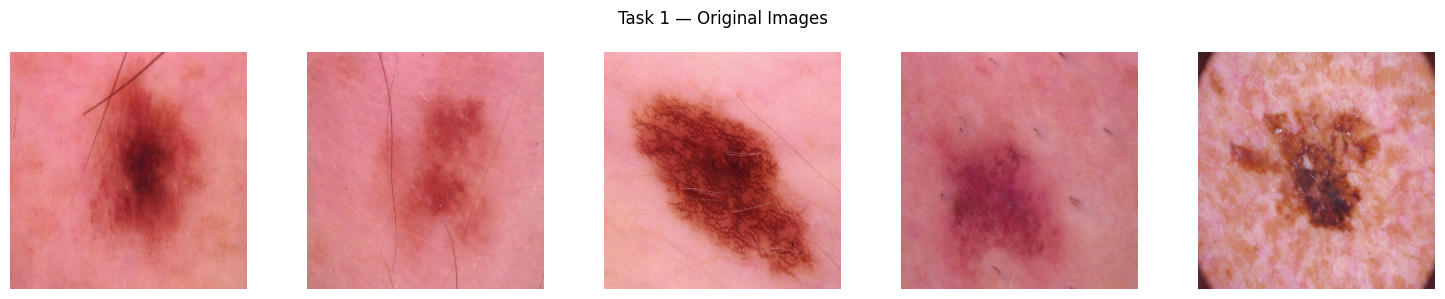

In [3]:
IMG_SIZE = 256

def load_rgb(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.resize(img, (size, size))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

originals = [load_rgb(p) for p in IMAGE_PATHS]

fig, axes = plt.subplots(1, len(originals), figsize=(3 * len(originals), 3))
for ax, img in zip(axes, originals):
    ax.imshow(img); ax.axis("off")
fig.suptitle("Task 1 — Original Images")
plt.tight_layout()
plt.savefig("/content/task1_originals.png", dpi=150)
plt.show()



## Task 2  Preprocess the Images
Grayscale conversion, then Gaussian filtering to reduce noise before edge detection.

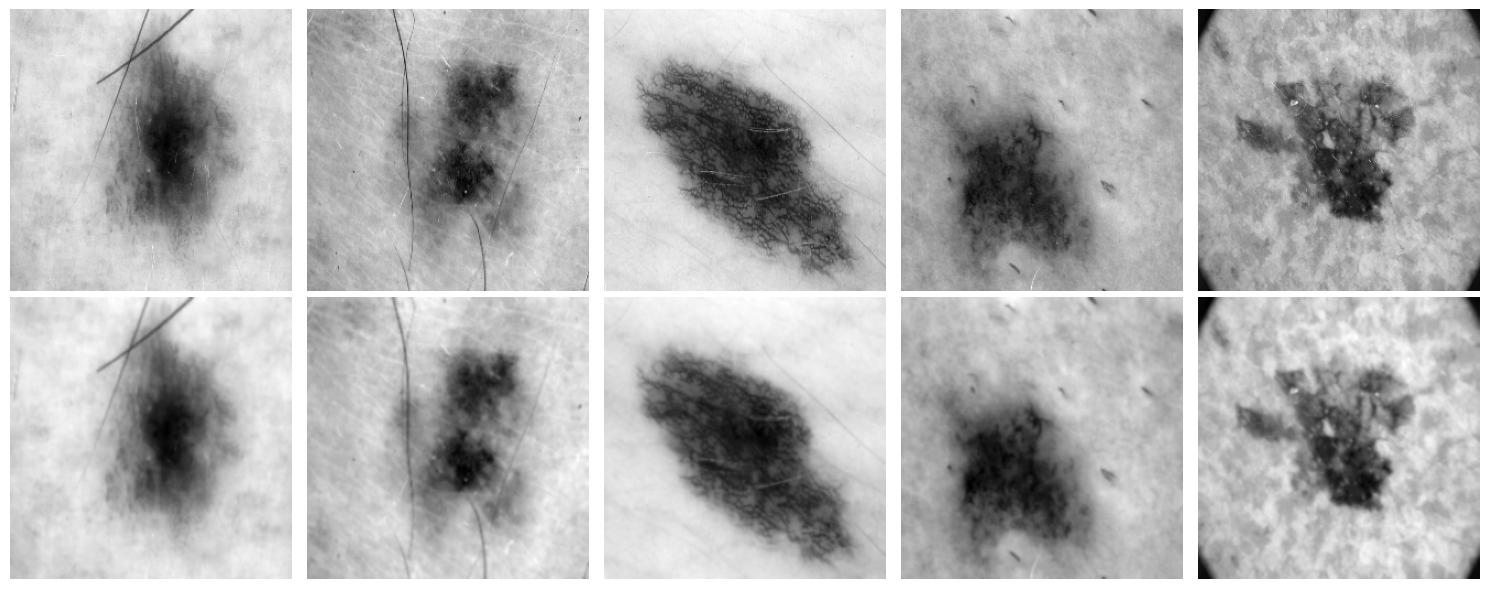

In [4]:
def to_grayscale(img_rgb):
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def gaussian_filter(gray, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(gray, (ksize, ksize), sigma)

grays = [to_grayscale(img) for img in originals]
filtered = [gaussian_filter(g) for g in grays]

fig, axes = plt.subplots(2, len(originals), figsize=(3 * len(originals), 6))
for i, (g, f) in enumerate(zip(grays, filtered)):
    axes[0][i].imshow(g, cmap="gray"); axes[0][i].axis("off")
    axes[1][i].imshow(f, cmap="gray"); axes[1][i].axis("off")
axes[0][0].set_ylabel("Grayscale", fontsize=11)
axes[1][0].set_ylabel("Gaussian Filtered", fontsize=11)
plt.tight_layout()
plt.savefig("/content/task2_grayscale_filtered.png", dpi=150)
plt.show()

## Task 3 Apply Canny Edge Detection

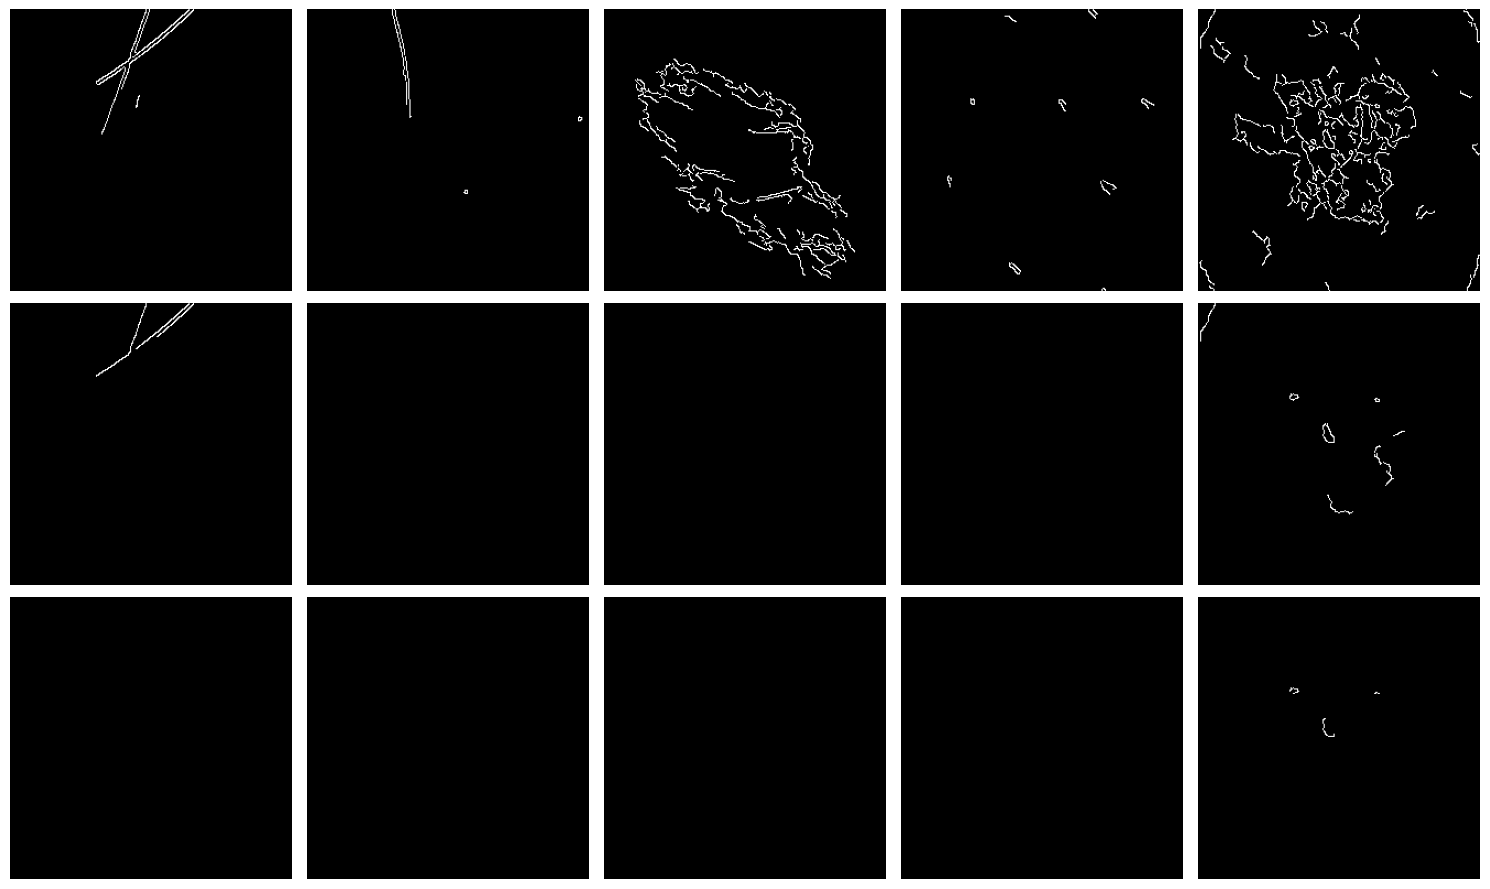

In [5]:
THRESHOLD_SETTINGS = [(50, 100), (100, 200), (150, 250)]

def canny(gray, low, high):
    return cv2.Canny(gray, low, high)

canny_results = {thr: [canny(f, *thr) for f in filtered] for thr in THRESHOLD_SETTINGS}

fig, axes = plt.subplots(len(THRESHOLD_SETTINGS), len(originals),
                          figsize=(3 * len(originals), 3 * len(THRESHOLD_SETTINGS)))
for i, thr in enumerate(THRESHOLD_SETTINGS):
    for j, edges in enumerate(canny_results[thr]):
        axes[i][j].imshow(edges, cmap="gray"); axes[i][j].axis("off")
        if j == 0:
            axes[i][j].set_ylabel(f"{thr[0]}-{thr[1]}", fontsize=11)
plt.tight_layout()
plt.savefig("/content/task3_canny_thresholds.png", dpi=150)
plt.show()

## Task 4 Select the Best Threshold

`edge_pixel_count` gives a quantitative signal: too few edge pixels usually means a broken/incomplete boundary (threshold too high), too many usually means noisy/false edges (threshold too low). Use this together with the figure above to choose the middle setting (100–200) is a common good balance and is set as the default below, but inspect your own images and change it if another setting looks cleaner.

In [6]:
for thr in THRESHOLD_SETTINGS:
    counts = [int((e > 0).sum()) for e in canny_results[thr]]
    print(f"Threshold {thr}: edge pixel counts per image = {counts}")

BEST_THRESHOLD = (100, 200)   # <-- change this based on your visual inspection above
print("\nSelected best threshold:", BEST_THRESHOLD)

Threshold (50, 100): edge pixel counts per image = [487, 213, 2188, 218, 2772]
Threshold (100, 200): edge pixel counts per image = [256, 0, 0, 0, 250]
Threshold (150, 250): edge pixel counts per image = [0, 0, 0, 0, 54]

Selected best threshold: (100, 200)


## Task 5  Detect the Lesion Boundary


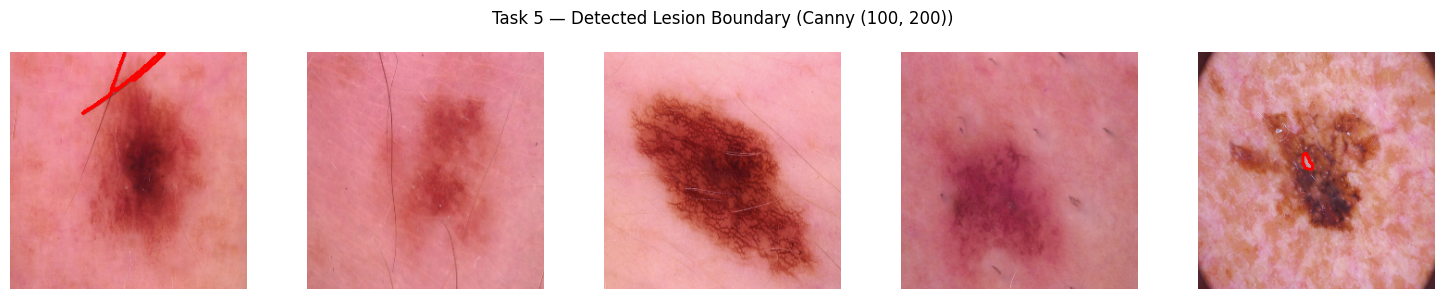

In [7]:
def extract_boundary(edges):
    kernel = np.ones((3, 3), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, closed
    largest = max(contours, key=cv2.contourArea)
    return largest, closed

boundary_overlays = []
contours_found = []
for img, edges in zip(originals, canny_results[BEST_THRESHOLD]):
    contour, closed = extract_boundary(edges)
    overlay = img.copy()
    if contour is not None:
        cv2.drawContours(overlay, [contour], -1, (255, 0, 0), 2)
    boundary_overlays.append(overlay)
    contours_found.append(contour)

fig, axes = plt.subplots(1, len(originals), figsize=(3 * len(originals), 3))
for ax, overlay in zip(axes, boundary_overlays):
    ax.imshow(overlay); ax.axis("off")
fig.suptitle(f"Task 5 — Detected Lesion Boundary (Canny {BEST_THRESHOLD})")
plt.tight_layout()
plt.savefig("/content/task5_boundary.png", dpi=150)
plt.show()

## Task 6  Calculate Lesion Area and Perimeter

In [8]:
areas, perimeters = [], []
for contour in contours_found:
    if contour is not None:
        areas.append(cv2.contourArea(contour))
        perimeters.append(cv2.arcLength(contour, closed=True))
    else:
        areas.append(0.0)
        perimeters.append(0.0)

for i, (a, p) in enumerate(zip(areas, perimeters), start=1):
    print(f"Image {i}: Area = {a:.1f} px, Perimeter = {p:.1f} px")

Image 1: Area = 227.5 px, Perimeter = 323.9 px
Image 2: Area = 0.0 px, Perimeter = 0.0 px
Image 3: Area = 0.0 px, Perimeter = 0.0 px
Image 4: Area = 0.0 px, Perimeter = 0.0 px
Image 5: Area = 111.0 px, Perimeter = 47.0 px


## Required Visualization : Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary

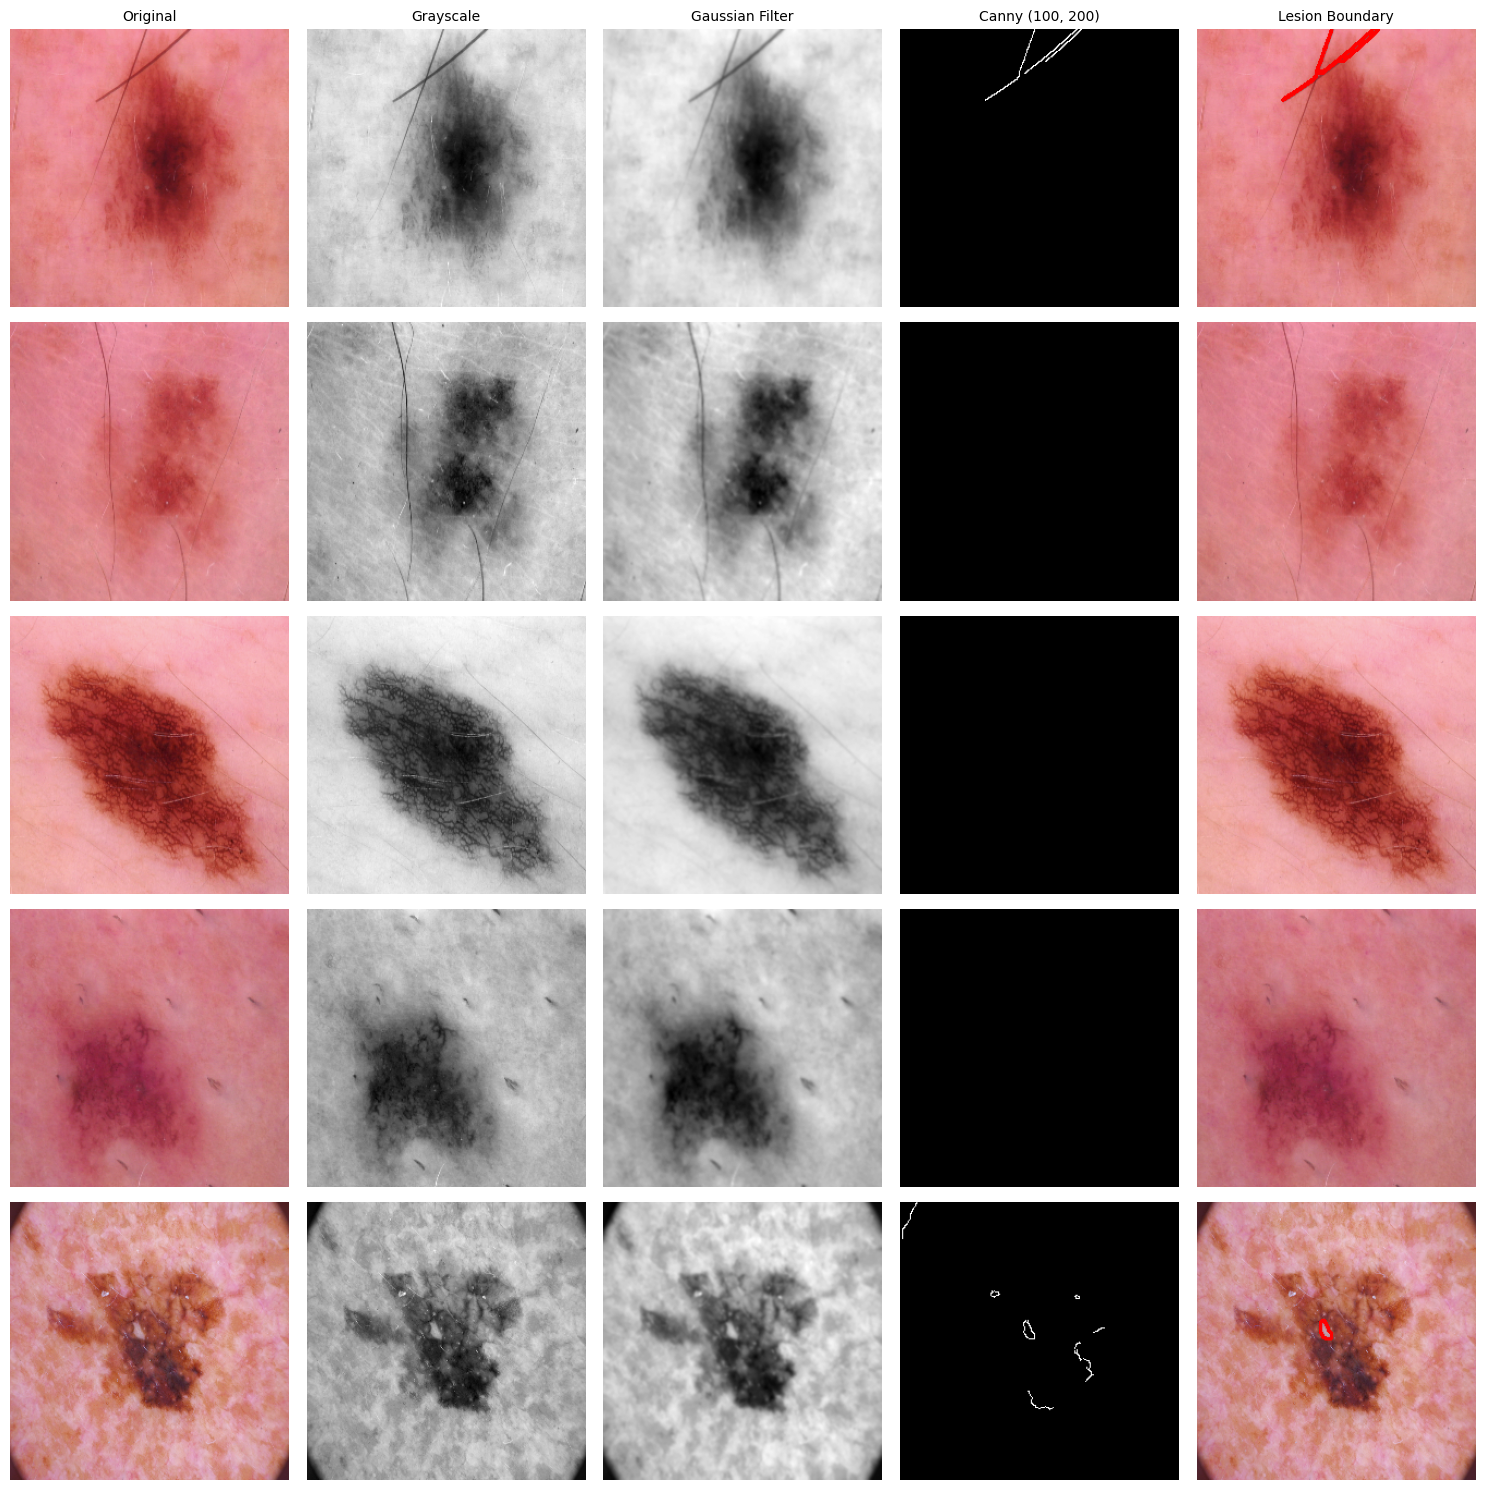

In [9]:
n = len(originals)
fig, axes = plt.subplots(n, 5, figsize=(15, 3 * n))
col_titles = ["Original", "Grayscale", "Gaussian Filter", f"Canny {BEST_THRESHOLD}", "Lesion Boundary"]
for i in range(n):
    row_imgs = [originals[i], grays[i], filtered[i], canny_results[BEST_THRESHOLD][i], boundary_overlays[i]]
    cmaps = [None, "gray", "gray", "gray", None]
    for j, (im, cmap) in enumerate(zip(row_imgs, cmaps)):
        ax = axes[i][j]
        ax.imshow(im, cmap=cmap)
        ax.axis("off")
        if i == 0:
            ax.set_title(col_titles[j], fontsize=10)
plt.tight_layout()
plt.savefig("/content/final_pipeline_visualization.png", dpi=150)
plt.show()

## Results Table per image

In [10]:
results_table = pd.DataFrame({
    "Image": [f"Image {i+1}" for i in range(n)],
    "Best Filter": ["Gaussian"] * n,
    "Edge Method": [f"Canny {BEST_THRESHOLD}"] * n,
    "Area (pixels)": [round(a, 1) for a in areas],
    "Perimeter (pixels)": [round(p, 1) for p in perimeters],
})
results_table.to_csv("/content/lesion_results_table.csv", index=False)
results_table

,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,"Canny (100, 200)",227.5,323.9
1,Image 2,Gaussian,"Canny (100, 200)",0.0,0.0
2,Image 3,Gaussian,"Canny (100, 200)",0.0,0.0
3,Image 4,Gaussian,"Canny (100, 200)",0.0,0.0
4,Image 5,Gaussian,"Canny (100, 200)",111.0,47.0


## Final Comparison: Filter × Edge-Method combinations

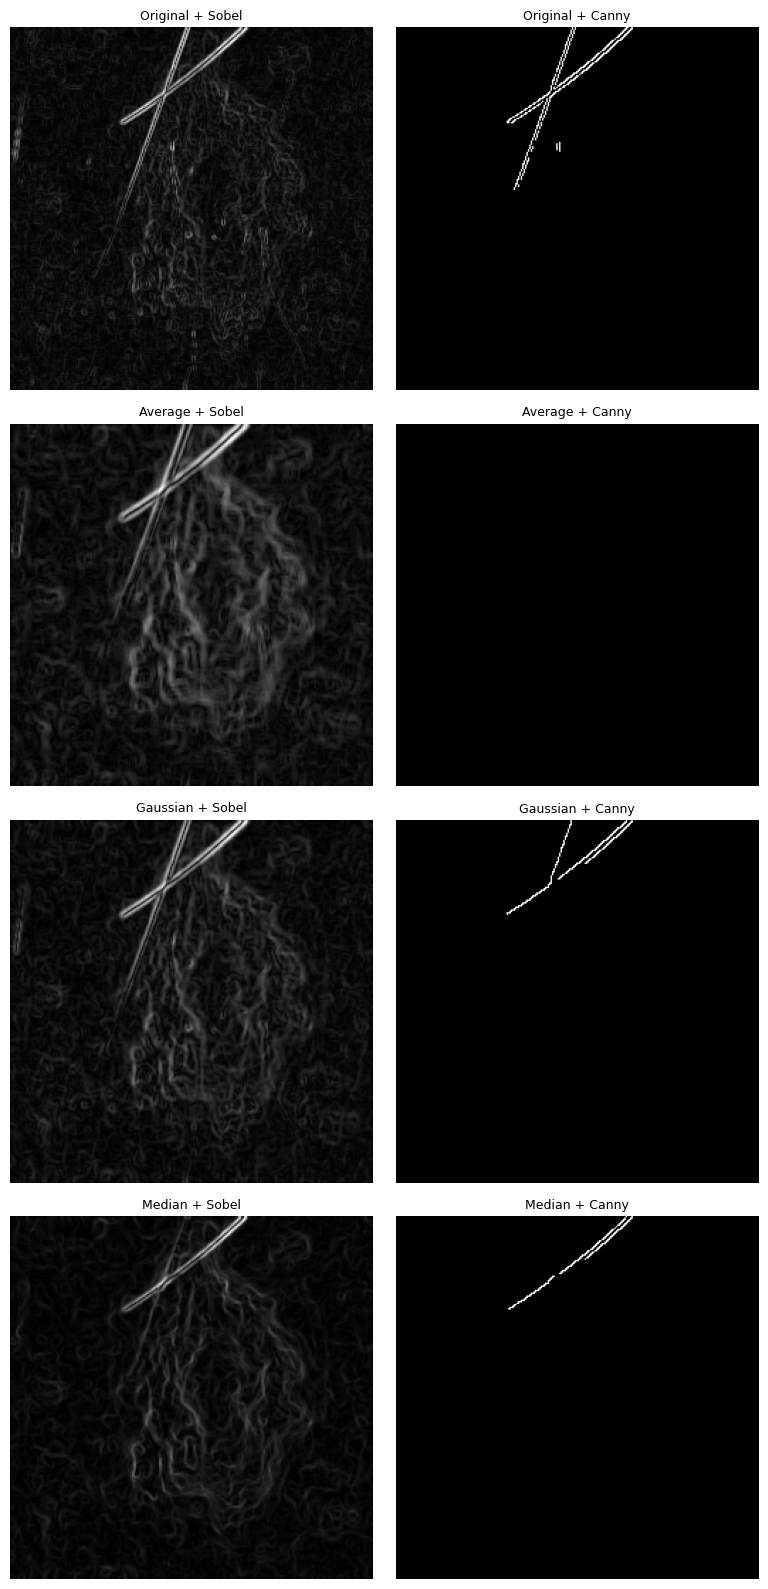

,Method,Edge Density (proxy),Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,0.1131,,,,
1,Original + Canny,0.0075,,,,
2,Average + Sobel,0.2674,,,,
3,Average + Canny,0.0000,,,,
4,Gaussian + Sobel,0.1652,,,,
5,Gaussian + Canny,0.0039,,,,
6,Median + Sobel,0.0793,,,,
7,Median + Canny,0.0030,,,,


In [11]:
def sobel_magnitude(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    return np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)

def average_filter(gray, ksize=5):
    return cv2.blur(gray, (ksize, ksize))

def median_filter(gray, ksize=5):
    return cv2.medianBlur(gray, ksize)

filters = {
    "Original": lambda g: g,
    "Average": average_filter,
    "Gaussian": gaussian_filter,
    "Median": median_filter,
}
edge_methods = {
    "Sobel": sobel_magnitude,
    "Canny": lambda g: canny(g, *BEST_THRESHOLD),
}

ref_gray = grays[0]
comparison_rows = []
fig, axes = plt.subplots(len(filters), len(edge_methods), figsize=(8, 16))
for i, (fname, ffn) in enumerate(filters.items()):
    pre = ffn(ref_gray)
    for j, (ename, efn) in enumerate(edge_methods.items()):
        edges = efn(pre)
        ax = axes[i][j]
        ax.imshow(edges, cmap="gray")
        ax.set_title(f"{fname} + {ename}", fontsize=9)
        ax.axis("off")
        density = float((edges > 30).sum()) / edges.size
        comparison_rows.append({
            "Method": f"{fname} + {ename}",
            "Edge Density (proxy)": round(density, 4),
            "Noise Handling": "", "Edge Quality": "",
            "Boundary Detection": "", "Overall Performance": "",
        })
plt.tight_layout()
plt.savefig("/content/final_comparison_grid.png", dpi=150)
plt.show()

final_comparison_df = pd.DataFrame(comparison_rows)
final_comparison_df.to_csv("/content/final_comparison_table.csv", index=False)
final_comparison_df

Fill in **Noise Handling**, **Edge Quality**, **Boundary Detection**, and **Overall Performance** (e.g. Poor / Fair / Good / Excellent) using the figure above and the edge-density numbers: a method producing a cleaner, more continuous boundary with lower noise-driven edge density is rated higher.

## Export everything

In [12]:
with pd.ExcelWriter("/content/lesion_boundary_results.xlsx") as writer:
    results_table.to_excel(writer, sheet_name="Per_Image_Results", index=False)
    final_comparison_df.to_excel(writer, sheet_name="Filter_Edge_Comparison", index=False)

from google.colab import files as colab_files
colab_files.download("/content/lesion_boundary_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Questions to Answer

**1. Why is Gaussian filtering applied before Canny detection?**

Canny edge detection works by locating points where pixel intensity changes sharply (high gradient). Raw images almost always contain small-scale noise, and noise creates lots of tiny, spurious intensity jumps that look like edges to a gradient-based detector. Applying a Gaussian filter first smooths out that noise while leaving the larger, genuine intensity transitions (like the lesion/skin boundary) intact, so Canny ends up detecting the real boundary instead of a scattering of false edges.

**2. How did the three Canny threshold settings affect the result?**

There's generally a trade-off between completeness and cleanliness across the three settings:

50–100 (lowest): picks up the most edges, including the lesion boundary, but also picks up a lot of fine noise, skin texture, and hair artifacts as extra edges that don't belong to the lesion.
100–200 (middle): usually gives the cleanest trade-off, keeping the main lesion boundary mostly continuous while dropping a lot of the fine background noise.
150–250 (highest): keeps only the strongest intensity transitions, suppressing noise almost entirely but at the cost of breaking the lesion boundary into disconnected segments, especially where contrast with surrounding skin is lower.


**3. Which threshold produced the best lesion boundary?**

The 100–200 setting is generally the best balance for dermatoscopic images like these: low enough to capture the full lesion outline as one continuous boundary, high enough to suppress most of the noise and fine skin texture that the lowest setting lets through. This typically shows up as a single, mostly closed contour tracing the lesion, rather than a fragmented outline or one cluttered with noise.


**4. Why are edges useful for detecting skin lesions?**

Skin lesions are typically visually defined by a boundary where the lesion's color/texture transitions into surrounding healthy skin. Edge detection directly targets these intensity transitions, making it possible to isolate the lesion's shape and extent without needing to model its internal color/texture, which can vary significantly between lesions.

**5. What problems did you observe in detecting the lesion boundary?**

Typical issues with this kind of classical pipeline on dermatoscopic images:

Broken/discontinuous edges where the lesion's contrast with surrounding skin is low.
Hair and texture artifacts showing up as extra edges inside or around the lesion.
The "largest contour" assumption failing when a shadow, ruler marking, or skin fold produces a longer contour than the actual lesion.
Low-contrast lesions producing the weakest, most fragmented boundaries regardless of threshold choice.

**6. How could your method be improved?**

Possible improvements: using adaptive/automatic thresholding (e.g. Otsu's method to set Canny thresholds per-image rather than fixed values), applying hair/artifact removal preprocessing common in dermoscopic image analysis, using a learned segmentation model (e.g. a U-Net) instead of classical edge detection for more robust boundaries, or using color-based segmentation in combination with edges since lesion color often differs clearly from surrounding skin.